# **Verification Lab2 - NLP Medical Question Filtering**


***
# Setup

## Imports

In [1]:
# General imports
import os
from datetime import datetime
import time

import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import uuid

# Plots
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Embedding
from sentence_transformers import SentenceTransformer



In [2]:
# Check Installs
#

import sys
import platform

print("System Information:")
print("=" * 50)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Architecture: {platform.architecture()}")
print()

conda_env = os.environ.get('CONDA_DEFAULT_ENV', 'Unknown')
print(f"Conda Environment: {conda_env}")
print()

!pip list | grep -E "(pandas|numpy|matplotlib|scikit-learn|tensorflow|tensorflow-metal|keras-tuner|sentence-transformers)"

System Information:
Python version: 3.11.0 | packaged by conda-forge | (main, Jan 14 2023, 12:25:12) [Clang 14.0.6 ]
Platform: macOS-15.6-arm64-arm-64bit
Architecture: ('64bit', '')

Conda Environment: CDT_DAIR_v1

keras-tuner             1.4.7
matplotlib              3.10.6
matplotlib-inline       0.1.7
numpy                   1.23.5
pandas                  2.3.2
scikit-learn            1.7.1
sentence-transformers   5.1.1
tensorflow              2.12.0
tensorflow-estimator    2.12.0


## Project Setup

In [3]:
# Project Setup
#

#---- Run Parameters --------------------------------
run_name = 'Test_Run_2'

#----------------------------------------------------

# Folder paths
local_project_folder = Path.cwd().parent
data_folder = local_project_folder.joinpath('Data')
if not data_folder.exists():
    raise FileNotFoundError(f'{data_folder} does not exist')
results_folder = local_project_folder.joinpath('Results')
if not results_folder.exists():
    raise FileNotFoundError(f'{results_folder} does not exist')

# Run Results
# run_name = f"Run_{run_name}_{datetime.now().strftime('%Y%m%d')}"
run_results_folder = results_folder.joinpath(f'{run_name}')
run_results_folder.mkdir(parents=True, exist_ok=True) 

del local_project_folder, results_folder, run_name

***
# Medical Datasets Load & Prep

In [4]:
# Prepare the datasets from the local data folder
#

# Combines two datsets
# - medicheck-expert.csv using expert classifications 0: as 'Non-Medical' (1) and 1,2,3 as 'Medical' (0)
# - medicheck-neg.csv as 'Non-Medical'

# Save df:
# Results/
#     xx run name xx/
#         query_data_raw.pkl


# Load two datasets & combine
# NB query_label_expert = 999 denotes no expert labeling
expert_df = pd.read_csv(data_folder.joinpath('medicheck-expert.csv'))
neg_df = pd.read_csv(data_folder.joinpath('medicheck-neg.csv'), header=None, names = ['query', 'query-label-expert'], escapechar='\\')
neg_df['query-label-expert'] = 999

# Combine the two datasets
expert_df = expert_df[['query', 'query-label-expert']]
combined_df = pd.concat([expert_df, neg_df], ignore_index=True)

# Classify the querys into types
# 'Non-Medical' (1) and 'Medical' (0)
combined_df['query-is-non-medical'] = combined_df['query-label-expert'].isin([0,999])

# Add a unique ref-id for later back-tracking
combined_df.insert(0, 'ref-id', [str(uuid.uuid4())[:8] for _ in range(len(combined_df))])

# Save to raw dataset
combined_df.to_pickle(run_results_folder.joinpath('query_data_raw.pkl'))


Full Dataset shape: (2916, 4)


,ref-id,query,query-label-expert,query-is-non-medical
0,eaca0d9a,Why do i get a bad headache when i don't eat e...,2,False
1,d6777884,What causes heart rate to suddenly quicken to ...,2,False
2,fce006aa,peritonsillar abscess drainage aftercare.. ple...,2,False
3,6c628d99,How serious is Mono or tonsillitis when untrea...,2,False
4,aad7522d,What are your chances of dying in your sleep?,1,False
5,97fc7340,"Bad reaction to anti-depression meds, wonderin...",2,False
6,bd4e5024,What are these white bumps in my nostrils? Is ...,1,False
7,31b73abb,What can I do to avoid these nail infections?,1,False
8,6e842074,What can I do to prevent/reverse possible hear...,2,False
9,88e3da50,Help with a mole,2,False


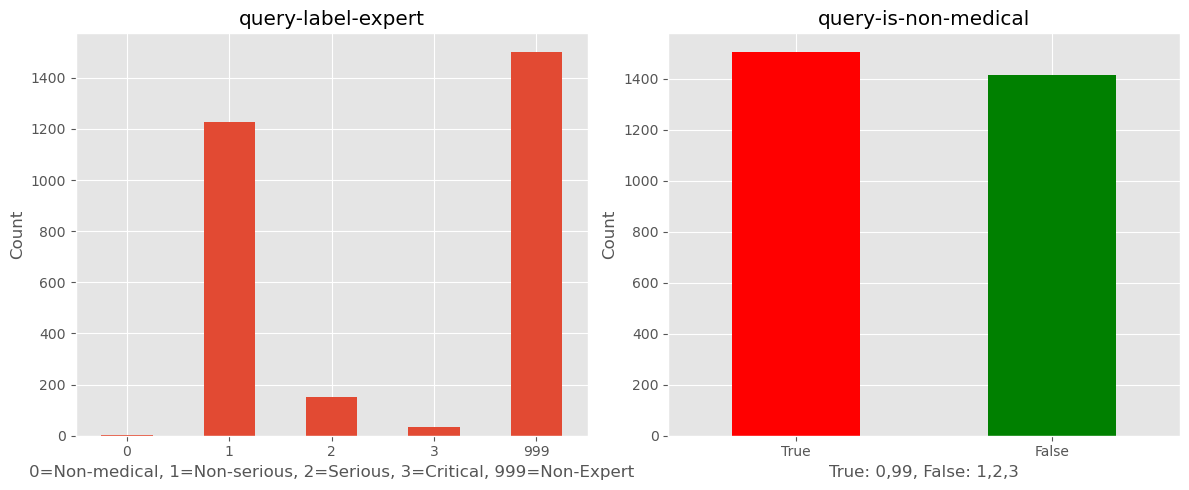

In [5]:
# Quick look at the data
# 

print(f"Full Dataset shape: {combined_df.shape}")
display(combined_df.head(10))

# Plot unbalanced labels
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

combined_df['query-label-expert'].value_counts().sort_index().plot(kind='bar', ax=axs[0])
axs[0].set_title('query-label-expert')
axs[0].set_xlabel('0=Non-medical, 1=Non-serious, 2=Serious, 3=Critical, 999=Non-Expert')
axs[0].set_ylabel('Count')
axs[0].tick_params(axis='x', rotation=0)

combined_df['query-is-non-medical'].value_counts().plot(kind='bar', ax=axs[1], color=['red', 'green'])
axs[1].set_title('query-is-non-medical')
axs[1].set_xlabel('True: 0,99, False: 1,2,3')
axs[1].set_ylabel('Count')
axs[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


***
# Sentence Embedding

In [6]:
# Sentence embedding function
#

def create_embeddings(sentences):
    # TODO: Understand why vector allignment is needed and how it is performed, see Antonio
    # See https://www.kaggle.com/discussions/general/566301

    # SBERT with all-MiniLM-L6-V2, a small and fast model, 385 dimensions
    # ANTONIO: encoding_models = {'all-MiniLM-L6-v2': 'sbert22M'}
    sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = sbert_model.encode(sentences, convert_to_numpy=True, show_progress_bar=True)


    # Allign vectors to the axis and rotate
    u, s, vh = np.linalg.svd(a=embeddings)
    align_mat = np.linalg.solve(a=vh, b=np.eye(len(embeddings[0])))
    embeddings = np.matmul(embeddings, align_mat)
    print(f"Embeddings shape: {embeddings.shape}")

    return embeddings

In [7]:
# Embed query sentences
#

# Save df:
# Results/
#     xx run name xx/
#         query_data_embeddings.pkl

# TODO: Have not split neg and pos, ANTONIO has though????
# TODO: Spliting X,y AFTER embeddings, ditto ANTONIO .....

# From the raw training dataset & add embeddings
query_df = combined_df.copy()
query_df['query-embedding'] = list(create_embeddings(query_df['query'].values))
print(f"Query Embeddings df shape: {query_df.shape}")

# Save
query_df.to_pickle(run_results_folder.joinpath('query_data_embeddings.pkl'))

Batches:   0%|          | 0/92 [00:00<?, ?it/s]

Embeddings shape: (2916, 384)
Query Embeddings df shape: (2916, 5)


***
# WIP - Feature Visualisation

In [ ]:
# TODO: Visualise feature entanglement etc, using clustering

# Word embeddings disentanglement: https://aclanthology.org/2020.aacl-main.72.pdf
# look at PCA, t-SNE and UMAP eg https://voxel51.com/blog/how-to-visualize-your-data-with-dimension-reduction-techniques



In [ ]:
# Quick cosine similarity

test_a = query_df.iloc[5:8]
test_b = query_df.iloc[9:15]
queries_a = test_a['query'].tolist()
queries_b = test_b['query'].tolist()
embeddings_a = np.array(test_a['query-embedding'].to_list())
embeddings_b = np.array(test_b['query-embedding'].to_list())

# Compute cosine similarities
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
similarities = sbert_model.similarity(embeddings_a, embeddings_b)

# Output the pairs with their score
for idx_i, sentence in enumerate(queries_a):
    print(sentence)
    for idx_j, sentence2 in enumerate(queries_b):
        print(f" - {sentence2: <30}: {similarities[idx_i][idx_j]:.4f}")

In [ ]:
# conda install umap-learn


In [ ]:
# Dimension reduction and clustering libraries
import umap
# import hdbscan
import sklearn.cluster as cluster
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score